# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Muhammad Athaa Rafi Khairan
- **Email:** cdcc312d6y1762@student.devacademy.id
- **ID Dicoding:** CDCC312D6Y1762

## Menentukan Pertanyaan Bisnis

- Bagaimana tren bulanan jumlah pesanan, GMV, dan AOV selama 2017-2018?

- Berapa proporsi pelanggan dengan lebih dari 3 pesanan selama 2017-2018, dan berapa kontribusi pendapatannya?


## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
orders_d = pd.read_csv('orders_dataset.csv')
print(orders_d.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [3]:
order_i_d = pd.read_csv('order_items_dataset.csv')
print(order_i_d.head())

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3  2018-08-15 10:10:18   12.99          12.7

In [4]:
customers_d = pd.read_csv('customers_dataset.csv')
print(customers_d.head())

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  


In [5]:
p1 = pd.merge(orders_d, order_i_d, how='inner', on='order_id')

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for col in date_columns:
    if col in p1.columns:
        p1[col] = pd.to_datetime(p1[col])

print(p1.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06 2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39 2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15

In [6]:
p2 = pd.merge(
    orders_d[['order_id', 'customer_id', 'order_purchase_timestamp']],
    customers_d[['customer_id', 'customer_unique_id']],
    how='inner',
    on='customer_id'
 )

print(p2.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_purchase_timestamp                customer_unique_id  
0      2017-10-02 10:56:33  7c396fd4830fd04220f754e42b4e5bff  
1      2018-07-24 20:41:37  af07308b275d755c9edb36a90c618231  
2      2018-08-08 08:38:49  3a653a41f6f9fc3d2a113cf8398680e8  
3      2017-11-18 19:28:06  7c142cf63193a1473d2e66489a9ae977  
4      2018-02-13 21:18:39  72632f0f9dd73dfee390c9b22eb56dd6  


In [7]:
p1_filter = p1[(
    p1['order_purchase_timestamp'] >= '2017-01-01') &
     (p1['order_purchase_timestamp'] < '2019-01-01')].copy()

p2_filter = p2[(
    p2['order_purchase_timestamp'] >= '2017-01-01') &
      (p2['order_purchase_timestamp'] < '2019-01-01')].copy()

**Insight:**
- Data diatas merupakan data gabungan dari 2 dataset yang akan dipakai untuk menjawab 2 pertanyaan bisnis
- Alasan penggunaan dataset tersebut karena kita dapat mengetahui harga, customer, waktu pembelian, dan beberapa kommponen lain untuk membantu memberikan insight atas pertanyaan bisnis yang sudah dibuat

### Assessing Data

In [8]:
p1_filter.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1157
order_delivered_customer_date    2407
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
dtype: int64

In [9]:
p1_filter.duplicated().sum()

np.int64(0)

In [10]:
p1_filter.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value
count,112280,112265,111123,109873,112280,112280.000000,112280,112280.000000,112280.000000
mean,2018-01-02 11:50:23.727885568,2018-01-02 23:24:02.497777664,2018-01-06 10:05:02.576001536,2018-01-15 20:47:19.834554624,2018-01-26 05:22:33.815461632,1.197613,2018-01-09 03:09:31.718017792,120.607925,19.990312
min,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-06 12:43:41,2017-01-11 13:14:05,2017-02-01 00:00:00,1.000000,2017-01-09 11:56:06,0.850000,0.000000
25%,2017-09-15 08:47:31.750000128,2017-09-15 15:15:16,2017-09-19 18:33:37.500000,2017-09-27 22:39:48,2017-10-06 00:00:00,1.000000,2017-09-21 15:06:15,39.900000,13.080000
50%,2018-01-20 20:58:01.500000,2018-01-22 13:51:08,2018-01-24 23:09:52,2018-02-03 15:53:07,2018-02-16 00:00:00,1.000000,2018-01-26 17:37:17.500000,74.990000,16.260000
75%,2018-05-04 23:19:18,2018-05-05 12:53:18,2018-05-08 14:08:30,2018-05-15 21:47:23,2018-05-28 00:00:00,1.000000,2018-05-10 16:30:27.249999872,134.900000,21.150000
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,2020-04-09 22:35:08,6735.000000,409.680000
std,NaN,NaN,NaN,NaN,NaN,0.704974,NaN,183.644086,15.809781


In [11]:
p2_filter.isnull().sum()

order_id                    0
customer_id                 0
order_purchase_timestamp    0
customer_unique_id          0
dtype: int64

In [12]:
p2_filter.duplicated().sum()

np.int64(0)

In [13]:
p2_filter.describe()

,order_id,customer_id,order_purchase_timestamp,customer_unique_id
count,99112,99112,99112,99112
unique,99112,99112,98546,95780
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2018-07-28 13:11:22,8d50f5eadf50201ccdcedfb9e2ac8455
freq,1,1,3,17


**Insight:**
- Tidak ditemukan data duplikat pada kedua tabel
- terdapat 3 kolom yang memiliki nilai null pada p1, yaitu order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date
- tidak ada kolom null pada tabel p2

### Cleaning Data

In [14]:
p1_filter['order_approved_at'] = p1_filter['order_approved_at'].ffill()

print("Jumlah Missing Values di order_approved_at setelah cleaning:")
print(p1_filter['order_approved_at'].isnull().sum())

Jumlah Missing Values di order_approved_at setelah cleaning:
0


In [15]:
p1[p1.order_delivered_carrier_date.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,1,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-04-19 13:25:17,49.9,16.05
118,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21,1,1522589c64efd46731d3522568e5bc83,28405831a29823802aa22c084cfd0649,2018-08-13 06:15:14,35.0,15.35
148,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03,1,61d52f4882421048afd530db53d6f230,fa74b2f3287d296e9fbd2cc80f2d1cf1,2017-09-20 14:30:09,125.9,12.38
368,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaT,NaT,2016-12-09,1,ca17b18b38db6e0d2c33d362322f2a06,4be2e7f96b4fd749d52dff41f80e39dd,2016-10-21 16:24:45,267.0,32.84
447,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaT,NaT,2018-08-14,1,ad673c1cd02b966e931f9db4fdc34791,9646c3513289980f17226a2fc4720dbd,2018-08-14 04:10:26,25.0,8.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112224,46bdec7cc92d926500bee756ee1df6dc,0cfcefc0ed0af6a2e601540feeac24e7,invoiced,2018-07-16 13:20:06,2018-07-16 13:30:35,NaT,NaT,2018-08-06,1,b57109d3dd3821f2685c6035112fc9a9,620c87c171fb2a6dd6e8bb4dec959fc6,2018-07-20 13:30:24,89.9,22.56
112308,aea0db338150b526dde24f6fd953a5ed,379a02efdc6a56bd27f99b95fc2f6c06,processing,2017-12-26 21:56:13,2017-12-26 22:05:26,NaT,NaT,2018-01-26,1,aa428a8e4d587520f90d37a08030a812,b2ba3715d723d245138f291a6fe42594,2018-01-02 22:05:26,96.9,16.44
112317,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,NaT,NaT,2017-10-27,1,dc2410804cf782c5d87dbcd201b74e9b,897060da8b9a21f655304d50fd935913,2017-10-05 22:35:22,150.0,16.81
112318,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,NaT,NaT,2017-10-27,2,dc2410804cf782c5d87dbcd201b74e9b,897060da8b9a21f655304d50fd935913,2017-10-05 22:35:22,150.0,16.81


In [16]:
p1_filter.dropna(subset=['order_delivered_carrier_date', 'order_delivered_customer_date'], inplace=True)


In [17]:
p1_filter.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
dtype: int64

### **Insight (Cleaning Data):**
- Kita menggunakan .ffill() karena order_approved_at adalah data yang menunjukan bahwa order sudah di approved oleh penjual, pada data yang hilang saya mengasumsikan bahwa penjual lupa aproved dan langsung mengirimkan.
Oleh sebab itu saya menggunakan fillna sehingga diasumsikan waktu membeli dengan waktu approve itu sama
- 2 data yaitu order delivered carrier dan order delivered customer date saya menggunakan drop. Hal ini dikarenakan saya berasumsi bahwa barang dibatalkan/tidak jadi dibeli oleh pembeli sehingga barang tidak pernah sampai.

## Exploratory Data Analysis (EDA)

### Explore ...

In [18]:
p1_filter['total_order_value'] = (sum(p1_filter['price'] + p1_filter["freight_value"])) / (p1_filter['order_id'].nunique())

In [19]:
p1_filter.groupby(by="order_purchase_timestamp").agg({
    "order_id": "nunique",
    "price": "sum",
    "freight_value": "sum",
}).sort_values(by="order_purchase_timestamp", ascending=False)

,order_id,price,freight_value
order_purchase_timestamp,,,
2018-08-29 15:00:37,1,84.99,8.76
2018-08-29 14:52:00,1,24.90,8.33
2018-08-29 14:18:28,1,45.90,15.39
2018-08-29 14:18:23,1,418.00,92.96
2018-08-29 12:25:59,1,63.90,9.20
...,...,...,...
2017-01-05 12:11:23,1,9.90,8.72
2017-01-05 12:09:08,1,7.90,8.72
2017-01-05 12:06:36,1,2.90,8.72


In [29]:
# Membuat metrik GMV per baris transaksi
p1_filter = p1_filter.assign(
    GMV=lambda x: x['price'] + x['freight_value']
 )

# Agregasi bulanan untuk menjawab pertanyaan 1
hasil = p1_filter.groupby(p1_filter['order_purchase_timestamp'].dt.to_period('M')).agg(
    GMV=('GMV', 'sum'),
    Jumlah_Pesanan=('order_id', 'nunique')
).reset_index()

# Definisi AOV yang benar: total GMV bulanan / jumlah order unik bulanan
hasil['AOV'] = hasil['GMV'] / hasil['Jumlah_Pesanan']

hasil = hasil.rename(columns={'order_purchase_timestamp': 'Bulan'}).set_index('Bulan')
hasil = hasil.rename(columns={'Jumlah_Pesanan': 'Jumlah Pesanan'})

print(hasil)

                GMV  Jumlah Pesanan         AOV
Bulan                                          
2017-01   127482.37             750  169.976493
2017-02   271239.32            1653  164.089123
2017-03   414330.95            2546  162.738001
2017-04   390812.40            2303  169.697091
2017-05   566657.40            3545  159.846939
2017-06   490050.37            3135  156.315907
2017-07   566299.08            3872  146.254928
2017-08   645832.36            4193  154.026320
2017-09   700883.51            4149  168.928298
2017-10   751117.01            4478  167.734929
2017-11  1153229.37            7288  158.236741
2017-12   843078.29            5513  152.925502
2018-01  1077887.46            7069  152.480897
2018-02   966212.50            6556  147.378356
2018-03  1120598.24            7003  160.016884
2018-04  1132878.93            6798  166.648857
2018-05  1128774.52            6749  167.250633
2018-06  1011448.96            6096  165.920105
2018-07  1027286.52            6156  166

In [30]:
transaksi_p = p2_filter.groupby(by='customer_unique_id')['order_id'].nunique().reset_index(name='Total_Transaksi')

pelanggan_setia = transaksi_p[transaksi_p['Total_Transaksi'] > 3].sort_values(by='Total_Transaksi', ascending=False)

o_value = (
    p1_filter.groupby('order_id')[['price', 'freight_value']]
    .sum()
    .assign(order_revenue=lambda x: x['price'] + x['freight_value'])
    .reset_index()[['order_id', 'order_revenue']]
 )

oc_value = p2_filter.merge(o_value, on='order_id', how='inner')

ps_ids = set(pelanggan_setia['customer_unique_id'])
total_revenue = oc_value['order_revenue'].sum()
ps_juml = oc_value[oc_value['customer_unique_id'].isin(ps_ids)]['order_revenue'].sum()
ps_perc = ps_juml / total_revenue * 100

print(f"Total customer (2017-2018): {oc_value['customer_unique_id'].nunique()}")
print(f"Customer loyal (>3 pesanan) sebanyak: {pelanggan_setia.shape[0]}")
print(f"Kontribusi pendapatan pelanggan loyal terhadap keseluruhan revenue adalah {ps_perc:.2f}%")

Total customer (2017-2018): 93096
Customer loyal (>3 pesanan) sebanyak: 49
Kontribusi pendapatan pelanggan loyal terhadap keseluruhan revenue adalah 0.25%


**Insight:**
- Telah ditentukan juga terkait jumlah pesanan, GMV dan AOV dari keseluruhan penjualan setiap bulannya
- Telah diketahui bahwa terdapat customer yang melakukan pesanan berulang sampai 3 kali dalam waktu yang berbeda, dari keseluruhan terdapat 49 orang dan menyumbang sekitar 0.25% dari total revenue perusahaan

## Visualization & Explanatory Analysis

### Pertanyaan 1:

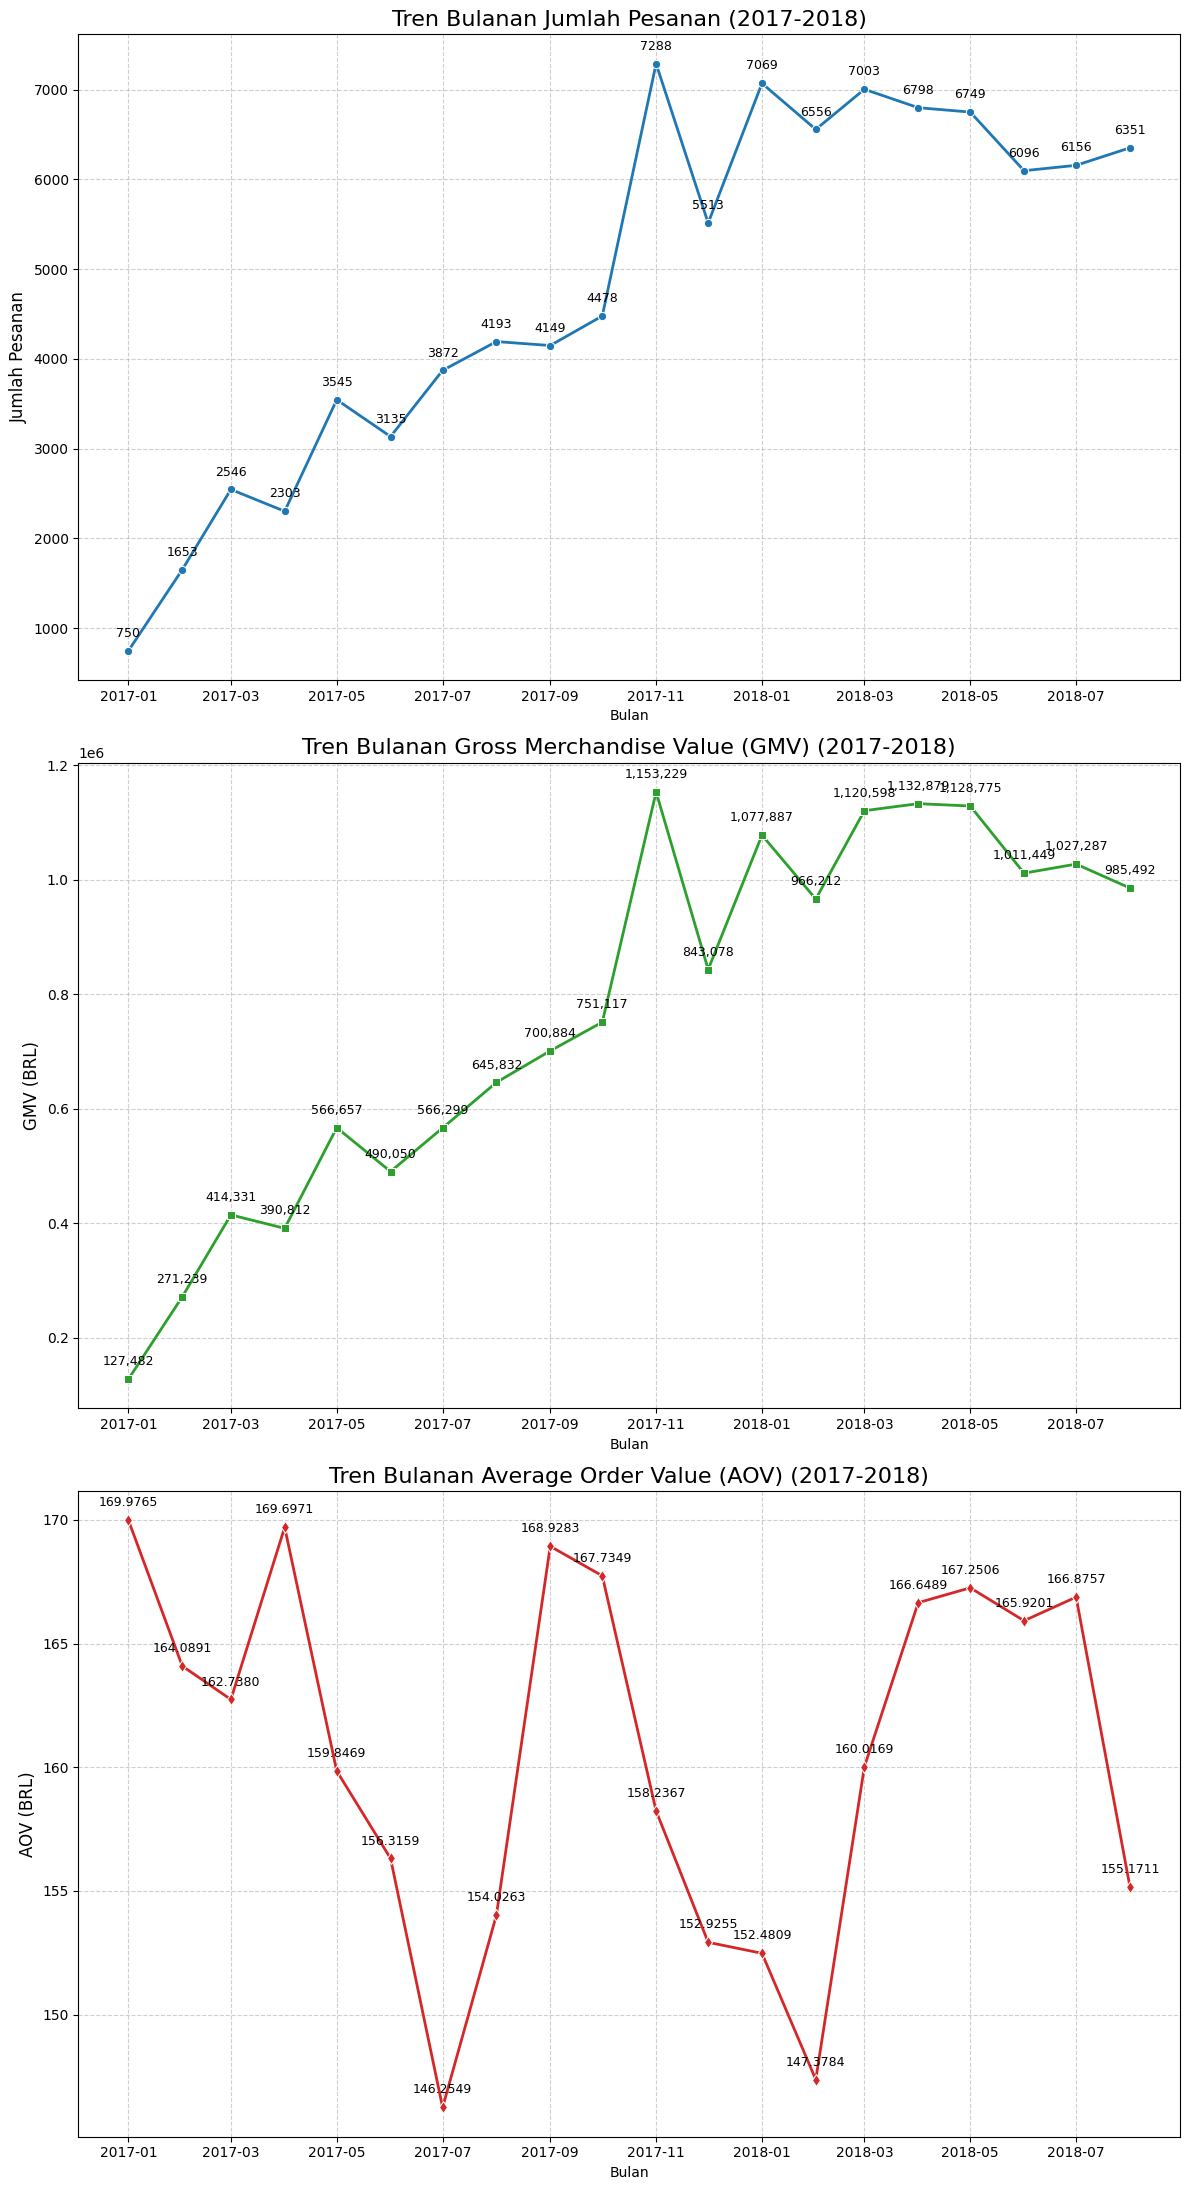

In [31]:
hasil_plot = hasil.copy()
hasil_plot.index = hasil_plot.index.to_timestamp()

#Jumlah Pesanan
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 22))

sns.lineplot(x=hasil_plot.index, y=hasil_plot['Jumlah Pesanan'], ax=ax[0], marker='o', color='tab:blue', linewidth=2)
ax[0].set_title('Tren Bulanan Jumlah Pesanan (2017-2018)', fontsize=16)
ax[0].set_ylabel('Jumlah Pesanan', fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.6)

for x, y in zip(hasil_plot.index, hasil_plot['Jumlah Pesanan']):
    ax[0].annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

#GMV
sns.lineplot(x=hasil_plot.index, y=hasil_plot['GMV'], ax=ax[1], marker='s', color='tab:green', linewidth=2)
ax[1].set_title('Tren Bulanan Gross Merchandise Value (GMV) (2017-2018)', fontsize=16)
ax[1].set_ylabel('GMV (BRL)', fontsize=12)
ax[1].grid(True, linestyle='--', alpha=0.6)

for x, y in zip(hasil_plot.index, hasil_plot['GMV']):
    ax[1].annotate(f'{y:,.0f}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

#AOV
sns.lineplot(x=hasil_plot.index, y=hasil_plot['AOV'], ax=ax[2], marker='d', color='tab:red', linewidth=2)
ax[2].set_title('Tren Bulanan Average Order Value (AOV) (2017-2018)', fontsize=16)
ax[2].set_ylabel('AOV (BRL)', fontsize=12)
ax[2].grid(True, linestyle='--', alpha=0.6)

for x, y in zip(hasil_plot.index, hasil_plot['AOV']):
    ax[2].annotate(f'{y:.4f}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

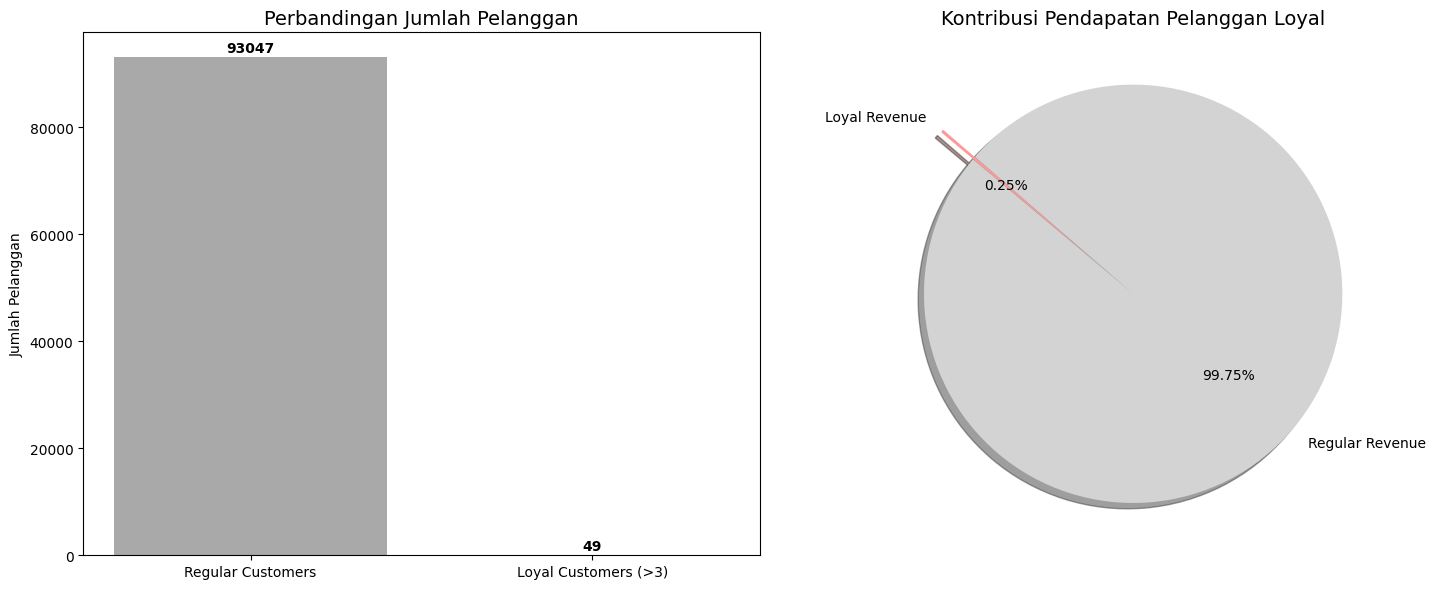

In [32]:
# Data untuk visualisasi
total_cust = oc_value['customer_unique_id'].nunique()
loyal_cust = pelanggan_setia['customer_unique_id'].nunique()
regular_cust = total_cust - loyal_cust

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Bar Chart: Jumlah Pelanggan
categories = ['Regular Customers', 'Loyal Customers (>3)']
counts = [regular_cust, loyal_cust]
ax[0].bar(categories, counts, color=['#A9A9A9', '#1f77b4'])
ax[0].set_title('Perbandingan Jumlah Pelanggan', fontsize=14)
ax[0].set_ylabel('Jumlah Pelanggan')
for i, v in enumerate(counts):
    ax[0].text(i, v + (max(counts)*0.01), str(v), ha='center', fontweight='bold')

# 2. Pie Chart: Kontribusi Pendapatan
labels = ['Regular Revenue', 'Loyal Revenue']
sizes = [100 - ps_perc, ps_perc]
colors = ['#D3D3D3', '#ff9999']
explode = (0, 0.2)  # Menonjolkan bagian loyal

ax[1].pie(sizes, explode=explode, labels=labels, autopct='%1.2f%%',
        shadow=True, startangle=140, colors=colors)
ax[1].set_title('Kontribusi Pendapatan Pelanggan Loyal', fontsize=14)

plt.tight_layout()
plt.show()

**Insight:**
- insight yang bisa didapatkan dari visualisasi nomor 1 adalah tren penjualan meningkat dari 2017 sampai 2018, namun AOV masih bersifat flutuatif
- terkait visualisasi nomor 2 adalah jumlah pelangggan yang melakukan transaksi berulang hanya ada 49 orang dan memiliki kontribusi cukup kecil pada keseluruhan pendapatan toko, yaitu hanya 0,25%

## Analisis Lanjutan (Opsional)

### Tujuan Teknik Analisis Lanjutan (RFM)
RFM analysis digunakan untuk memperdalam pertanyaan bisnis nomor 2 dengan memetakan kualitas pelanggan dari tiga aspek:
- Recency: seberapa baru pelanggan terakhir bertransaksi.
- Frequency: seberapa sering pelanggan melakukan transaksi.
- Monetary: seberapa besar nilai belanja pelanggan.

Dengan teknik ini, analisis tidak hanya berhenti pada proporsi pelanggan loyal, tetapi juga menghasilkan segmentasi yang lebih operasional untuk strategi retensi dan peningkatan repeat order.

In [24]:
#menggunakan analisa RFM

g_data = pd.merge(orders_d, order_i_d, on='order_id', how='inner')
rfm_data = pd.merge(g_data, customers_d, on='customer_id', how='inner')

rfm_data['order_purchase_timestamp'] = pd.to_datetime(rfm_data['order_purchase_timestamp'])

reference_d = rfm_data['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [25]:
tabel_rfm = rfm_data.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_d - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()

tabel_rfm['monetary'] = tabel_rfm['price'] + tabel_rfm['freight_value']

tabel_rfm.rename(columns={
    'order_purchase_timestamp': 'recency',
    'order_id': 'frequency'
}, inplace=True)

tabel_rfm = tabel_rfm[['customer_unique_id','monetary','recency','frequency']]

In [26]:
tabel_rfm['r_score'] = pd.qcut(tabel_rfm['recency'], 5, labels=[5, 4, 3, 2, 1])

tabel_rfm['f_score'] = pd.cut(tabel_rfm['frequency'],
                               bins=[0, 1, 2, 3, 5, np.inf],
                               labels=[1, 2, 3, 4, 5])

tabel_rfm['m_score'] = pd.qcut(tabel_rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])

tabel_rfm['RFM_Score'] = tabel_rfm['r_score'].astype(str) + tabel_rfm['f_score'].astype(str) + tabel_rfm['m_score'].astype(str)

print("Hasil Pemberian Skor RFM:")
print(tabel_rfm[['customer_unique_id', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'RFM_Score']].head())
tabel_rfm.info()

Hasil Pemberian Skor RFM:
                 customer_unique_id  recency  frequency  monetary r_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      116          1    141.90       4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     27.19       4   
2  0000f46a3911fa3c0805444483337064      542          1     86.22       1   
3  0000f6ccb0745a6a4b88665a16c9f078      326          1     43.62       2   
4  0004aac84e0df4da2b147fca70cf8255      293          1    196.89       2   

  f_score m_score RFM_Score  
0       1       4       414  
1       1       1       411  
2       1       2       112  
3       1       1       211  
4       1       4       214  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95420 entries, 0 to 95419
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   customer_unique_id  95420 non-null  object  
 1   monetary            95420 non-null  float64 
 2   recency           

In [27]:
def segment_customer_id(row):
    # Konversi nilai skor menjadi integer
    r = int(row['r_score'])
    f = int(row['f_score'])
    m = int(row['m_score'])

    # Logika pengkondisian untuk menentukan segmen
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2 and m >= 4:
        return 'Big Spenders'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    else:
        return 'Others'

# Menerapkan fungsi ke DataFrame tabel_rfm
tabel_rfm['Segment'] = tabel_rfm.apply(segment_customer_id, axis=1)

# Menghitung jumlah pelanggan per segmen
segment_distribution = tabel_rfm['Segment'].value_counts().reset_index()
segment_distribution.columns = ['Segment', 'Jumlah Pelanggan']

print("Distribusi Segmen Pelanggan:")
print(segment_distribution)

# Menampilkan sampel data dengan segmen baru
tabel_rfm[['customer_unique_id', 'RFM_Score', 'Segment']].head()

Distribusi Segmen Pelanggan:
           Segment  Jumlah Pelanggan
0           Others             56258
1     Big Spenders             23181
2      Hibernating             15741
3  Loyal Customers               134
4          At Risk                72
5        Champions                34


,customer_unique_id,RFM_Score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,414,Big Spenders
1,0000b849f77a49e4a4ce2b2a4ca5be3f,411,Others
2,0000f46a3911fa3c0805444483337064,112,Hibernating
3,0000f6ccb0745a6a4b88665a16c9f078,211,Hibernating
4,0004aac84e0df4da2b147fca70cf8255,214,Others


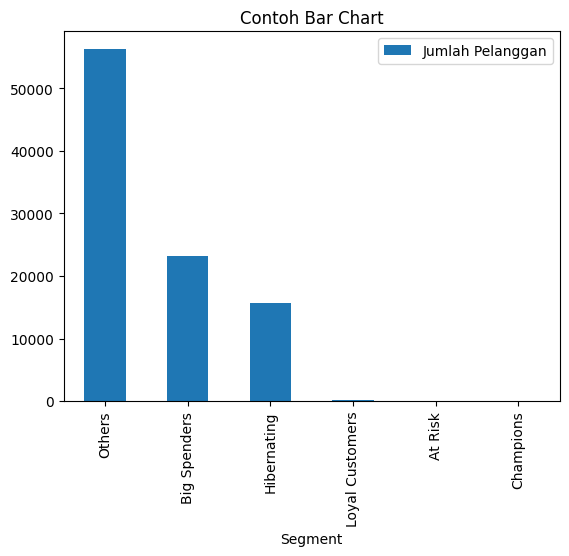

In [28]:
# Membuat Bar Chart
segment_distribution.plot.bar(x='Segment', y='Jumlah Pelanggan', rot=0, title="Contoh Bar Chart")
plt.xticks(rotation = 90)
plt.show()

## Conclusion

1. Pertanyaan 1: Tren bulanan jumlah pesanan dan GMV selama 2017-2018 cenderung meningkat. Namun, AOV masih berfluktuasi, yang menunjukkan kenaikan frekuensi transaksi belum selalu diikuti kenaikan nilai transaksi per order.

2. Pertanyaan 2: Pelanggan dengan lebih dari 3 pesanan berjumlah 49 orang dengan kontribusi pendapatan sekitar 0,25% dari total revenue. Artinya, basis pelanggan loyal masih kecil dan belum menjadi pendorong utama pendapatan.

3. Analisis lanjutan: Untuk memperdalam pertanyaan 2, digunakan RFM analysis (tanpa machine learning) untuk memetakan perilaku pelanggan. Hasil segmentasi menunjukkan dominasi segmen Others dan Big Spenders, sehingga strategi retensi dan aktivasi ulang pelanggan perlu diprioritaskan.

4. Rekomendasi bisnis: Fokus pada program peningkatan repeat order, seperti voucher repeat purchase, CRM reminder, dan loyalty benefit bertahap, serta kampanye personal untuk segmen bernilai tinggi agar kontribusi revenue dari pelanggan loyal meningkat.